In [1]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import seaborn as sns
from medpy.metric.binary import dc as dice_score

## Whole-image metrics
Dice

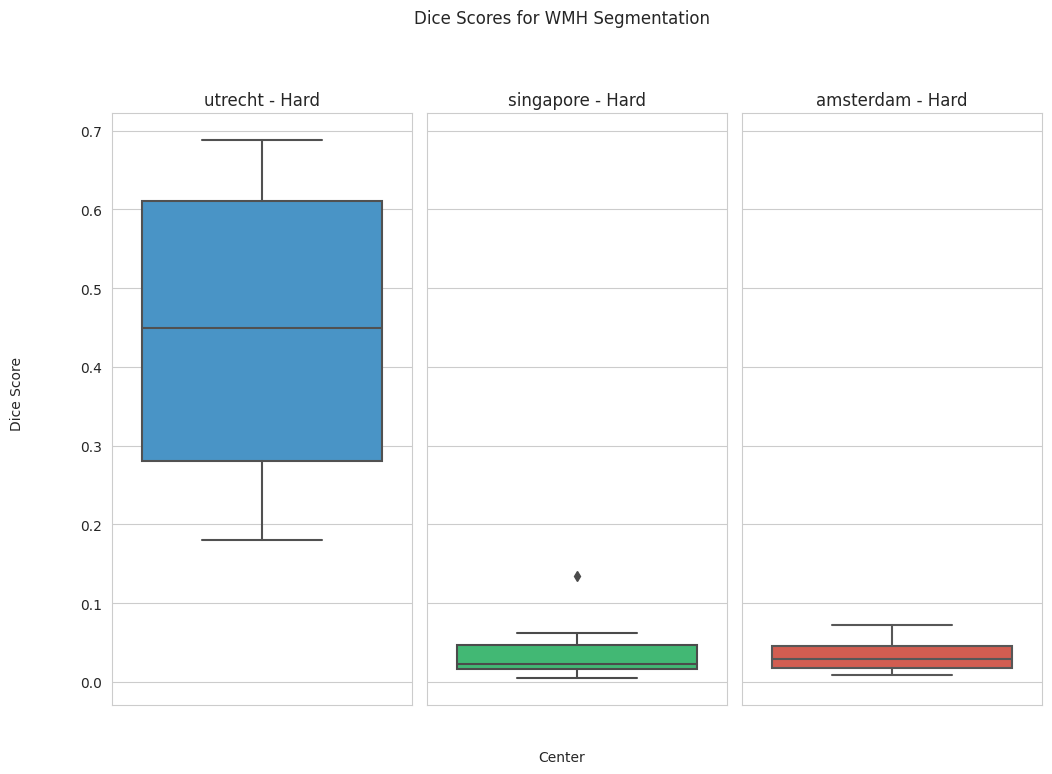

In [9]:
# Set seaborn style
sns.set_style('whitegrid')

# Define colors for each center
colors = ['#3498db', '#2ecc71', '#e74c3c']

centers = ['utrecht', 'singapore', 'amsterdam']
results = {}

for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']
    results[center] = {'hard': []}

    for _, row in df.iterrows():
        pred_hard_path, pred_softmax_path, logits_path, gt_path = row

        pred_hard = nib.load(pred_hard_path).get_fdata()
        gt = nib.load(gt_path).get_fdata()

        # Compute dice scores
        dice_hard = dice_score(pred_hard, gt)

        # Save results in dictionary
        results[center]['hard'].append(dice_hard)

# Create subplots using seaborn's boxplot
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 8), sharey=True)
for i, center in enumerate(centers):
    sns.boxplot(y=results[center]['hard'], color=colors[i], ax=axs[i])
    axs[i].set_title(f"{center} - Hard")

# Set axis labels and title
fig.suptitle('Dice Scores for WMH Segmentation')
fig.text(0.5, 0.04, 'Center', ha='center')
fig.text(0.04, 0.5, 'Dice Score', va='center', rotation='vertical')

# Adjust layout and save plot
fig.subplots_adjust(top=0.85, wspace=0.05)
plt.savefig('dice_scores.png', dpi=300, bbox_inches='tight')

## Class-wise metrics
Here the voxels are separated according to their class (0 or 1) and the metrics are computed for each class separately.
- Probabilities histogram from the softmax output
- Absolute logit values histogram

### Probabilities histogram

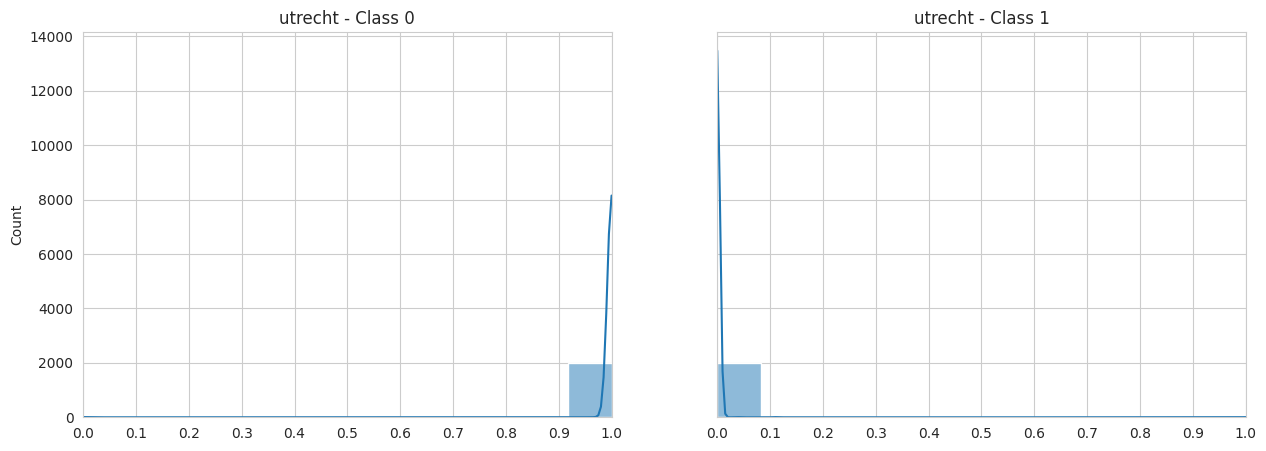

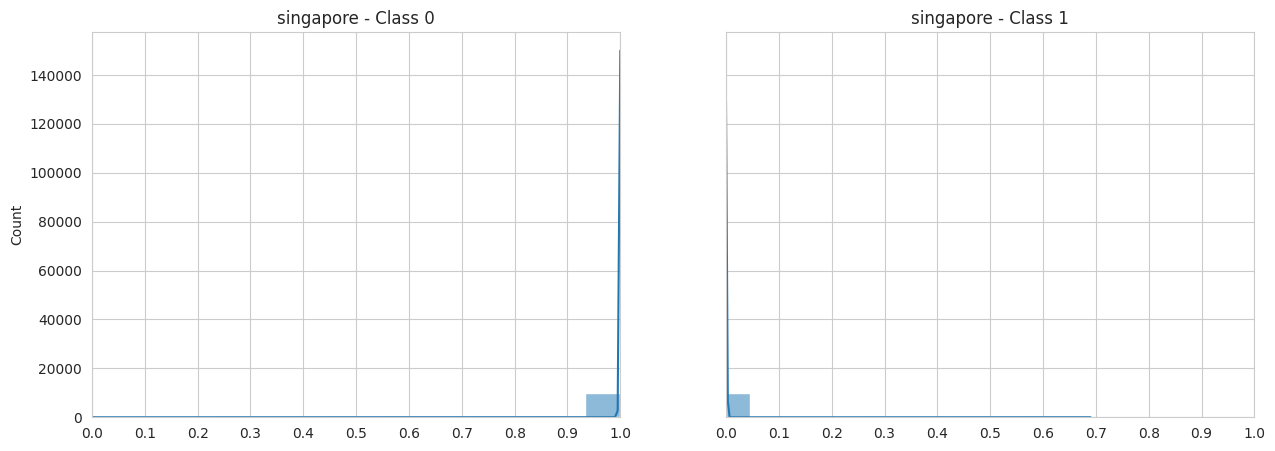

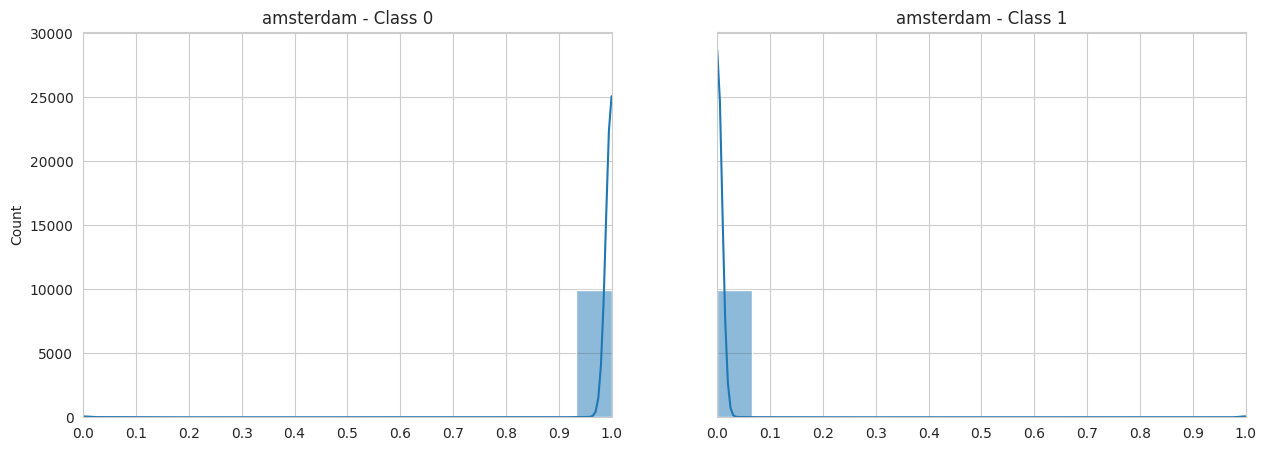

In [7]:
import random

centers = ['utrecht', 'singapore', 'amsterdam']
num_voxels = 500  # number of voxels to grab

for center in centers:
    vx_0_np = np.array([])
    vx_1_np = np.array([])
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    for _, row in df.iterrows():
        _, pred_wmh_softmax, _, _ = row

        pred_softmax = nib.load(pred_wmh_softmax).get_fdata()  # dims: [H, W, C, B, D]

        # Grab a random sample of voxels for each class
        voxels_0 = random.sample(list(pred_softmax[:, :, 0, 0, :].flatten()), num_voxels)
        voxels_1 = random.sample(list(pred_softmax[:, :, 1, 0, :].flatten()), num_voxels)

        # Concatenate sampled voxels for each class
        vx_0_np = np.concatenate((vx_0_np, np.around(np.array(voxels_0), decimals=2)))
        vx_1_np = np.concatenate((vx_1_np, np.around(np.array(voxels_1), decimals=2)))

    # Plot histogram for each voxel class
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharey=True)
    for i, voxels in enumerate([vx_0_np, vx_1_np]):
        sns.histplot(voxels, ax=axs[i], kde=True)
        axs[i].set_title(f"{center} - Class {i}")
        axs[i].set_xlim([0, 1])
        axs[i].set_xticks(np.arange(0, 1.1, 0.1))

    # fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 8), sharey=True)
    # for i, voxels in enumerate([vx_0_np, vx_1_np]):
    #     sns.histplot(voxels, ax=axs[i], kde=True)
    #     axs[i].set_title(f"{center} - Class {i} - Log scale")
    #     axs[i].set_xlim([0, 1])
    #     axs[i].set_xticks(np.arange(0, 1.1, 0.1))
    #     axs[i].set_yscale('log')

### Absolute logit values histogram

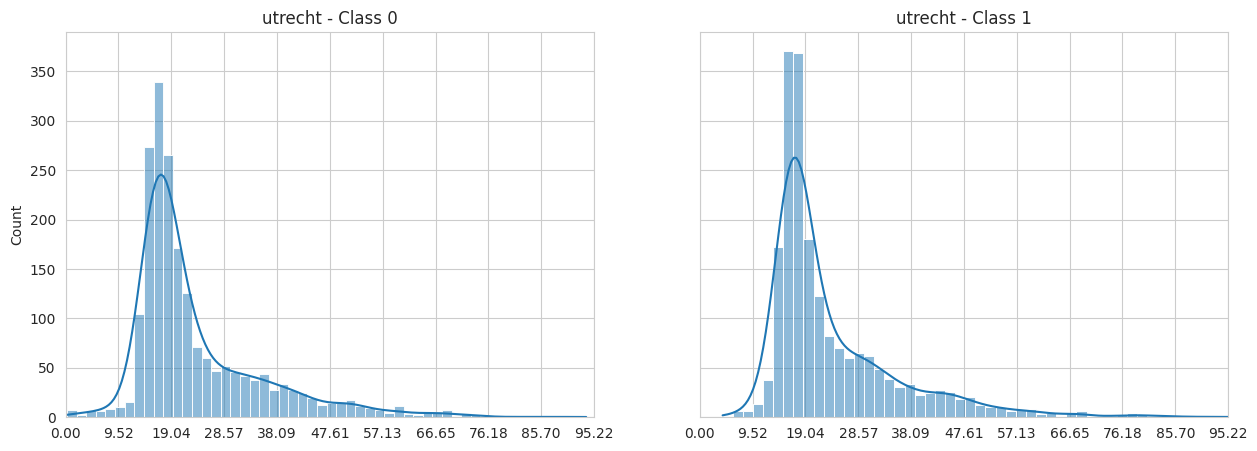

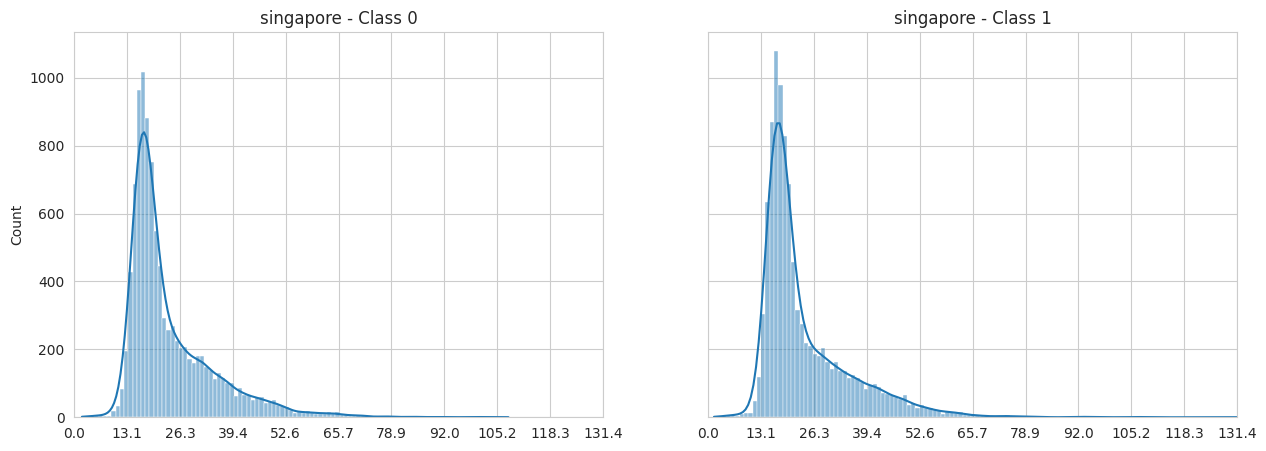

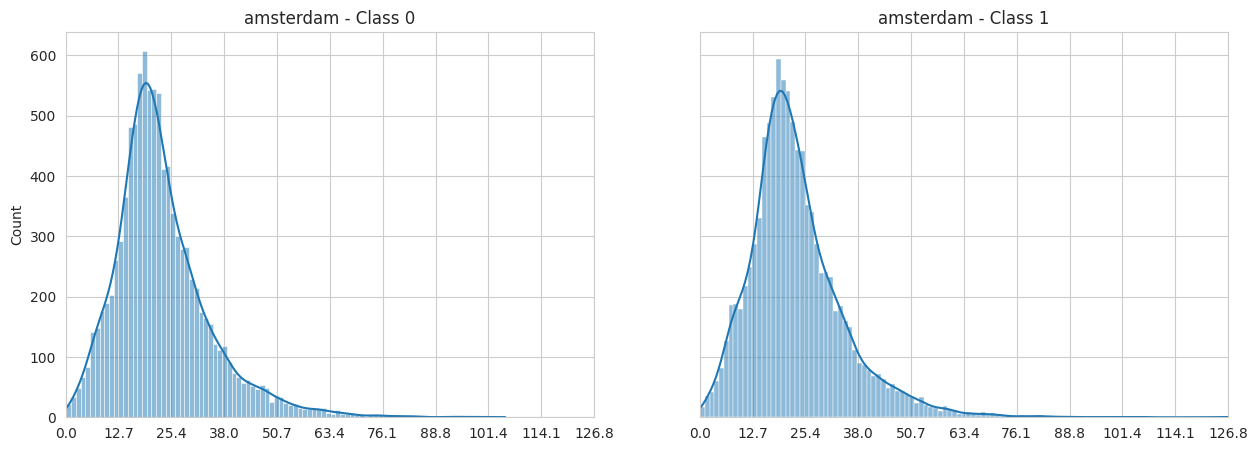

In [6]:
import random

centers = ['utrecht', 'singapore', 'amsterdam']
num_voxels = 500  # number of voxels to grab
n_x_ticks = 10

for center in centers:
    vx_0_np = np.array([])
    vx_1_np = np.array([])
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    for _, row in df.iterrows():
        _, _, pred_logits, _ = row

        pred_softmax = nib.load(pred_logits).get_fdata()  # dims: [H, W, C, B, D]

        # Grab a random sample of voxels for each class
        voxels_0 = random.sample(list(pred_softmax[:, :, 0, 0, :].flatten()), num_voxels)
        voxels_1 = random.sample(list(pred_softmax[:, :, 1, 0, :].flatten()), num_voxels)

        # Concatenate sampled voxels for each class (take absolute value and round at two decimals)
        vx_0_np = np.concatenate((vx_0_np, np.around(np.abs(np.array(voxels_0)), decimals=2)))
        vx_1_np = np.concatenate((vx_1_np, np.around(np.abs(np.array(voxels_1)), decimals=2)))

    # Plot histogram for each voxel class
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharey=True)
    for i, voxels in enumerate([vx_0_np, vx_1_np]):
        sns.histplot(voxels, ax=axs[i], kde=True)
        axs[i].set_title(f"{center} - Class {i}")
        axs[i].set_xlim([0, np.max([np.max(vx_0_np), np.max(vx_1_np)])])
        maxval = np.max([np.max(vx_0_np), np.max(vx_1_np)])
        axs[i].set_xticks(np.arange(0, maxval + 0.1, maxval / n_x_ticks))

    # fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 8), sharey=True)
    # for i, voxels in enumerate([vx_0_np, vx_1_np]):
    #     sns.histplot(voxels, ax=axs[i], kde=True)
    #     axs[i].set_title(f"{center} - Class {i} - Log scale")
    #     axs[i].set_xlim([0, 1])
    #     axs[i].set_xticks(np.arange(0, 1.1, 0.1))
    #     axs[i].set_yscale('log')

### ECE and reliability diagrams

In [ ]:
# ECE and reliability diagrams
from sklearn.calibration import calibration_curve

centers = ['utrecht', 'singapore', 'amsterdam']
for center in centers:
    df = pd.read_csv(f"utrecht-{center}.csv", header=None)
    df.columns = ['pred_wmh_hard', 'pred_wmh_softmax', 'pred_logits', 'gt_wmh']

    smx_np = np.array([])
    gt_np = np.array([])

    fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    for i, row in df.iterrows():
        _, pred_wmh_softmax, _, gt_wmh = row

        pred_softmax = nib.load(pred_wmh_softmax).get_fdata()  # dims: [H, W, C, B, D]
        gt_wmh = nib.load(gt_wmh).get_fdata()  # dims: [H, W, C, B, D]

        # Flatten the arrays and append to numpy array
        vals = np.round(pred_softmax[:, :, 1, 0, :].flatten(), decimals=2)
        smx_np = np.concatenate((smx_np, vals))
        gt_np = np.concatenate((gt_np, gt_wmh.flatten()))

    # Compute reliability diagram
    fraction_of_positives, mean_predicted_value = calibration_curve(gt_np, smx_np, n_bins=10)

    # Compute ECE
    ece = np.abs(fraction_of_positives - mean_predicted_value).mean()

    # Plot reliability diagram
    axs.plot(mean_predicted_value, fraction_of_positives, "s-",
                label="%s" % (center, ))

    axs.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    axs.set_ylabel("Fraction of positives")
    axs.set_ylim([-0.05, 1.05])
    axs.set_title(f"{center} - Reliability diagram")
    axs.legend(loc="lower right")
    axs.grid(True)
